In [1]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import pytorch_lightning as pl
import json
import numpy as np
from PIL import Image
from tqdm import tqdm
from random import shuffle
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from defCNN import CNN2D

# Training CNN on Spctrograms with fixed p-wave

## Data Loading

In [2]:
# Path to dataset
data_path_64 = "..\preprocessed_dset\sp_64"
data_path_32 = "..\preprocessed_dset\sp_32"
meta_path = r"..\preprocessed_dset\features_and_metadata.csv"

In [3]:
# Data stats for normalization

def calculate_and_save_stats(train_data_path, stats_file):
    print("Calculating dataset statistics for normalization...")
    all_pixels = []
    for root, dirs, files in os.walk(train_data_path):
        for file in tqdm(files, desc="Calculating stats", unit="image"):
            if file.endswith(".png"):
                img_path = os.path.join(root, file)
                image = Image.open(img_path).convert("RGB")
                all_pixels.append(np.array(image) / 255.0)
    all_pixels = np.concatenate([img.reshape(-1, 3) for img in all_pixels], axis=0)
    mean = all_pixels.mean(axis=0)
    std = all_pixels.std(axis=0)
    
    # Save statistics to a file
    with open(stats_file, "w") as f:
        json.dump({"mean": mean.tolist(), "std": std.tolist()}, f)
    
    
    return mean, std

def load_stats(stats_file):
    with open(stats_file, "r") as f:
        stats = json.load(f)
    mean = np.array(stats["mean"])
    std = np.array(stats["std"])
    return mean, std

def spectra_stats(data_path):
    stats_file = os.path.join(data_path, "stats.json")
    if os.path.exists(stats_file):
        mean, std = load_stats(stats_file)
        print(f"({data_path}) Mean: {mean}, Std: {std} (calculated and saved)")
    else:
        mean, std = calculate_and_save_stats(data_path, stats_file)
        print(f"({data_path}) Mean: {mean}, Std: {std} (loaded from file)")
    
    return mean, std
    
mean_64, std_64 = spectra_stats(os.path.join(data_path_64, "train"))
mean_32, std_32 = spectra_stats(os.path.join(data_path_32, "train"))

(..\preprocessed_dset\sp_64\train) Mean: [0.67176665 0.65817659 0.6412554 ], Std: [0.1186761  0.12021562 0.11939131] (calculated and saved)
(..\preprocessed_dset\sp_32\train) Mean: [0.65032865 0.63513704 0.61763785], Std: [0.12265336 0.12450042 0.12385332] (calculated and saved)


In [4]:
# Define Dataset and DataLoader
class SpectraDataset(Dataset):
    def __init__(self, data_path, transform=None, get_image_name=False, same_amount=False):
        self.data_path = data_path
        self.transform = transform
        self.file_list = [f for f in os.listdir(data_path) if f.endswith(".png")]
        if same_amount:
            self.file_list = self.take_same_amount()
        self.get_image_name = get_image_name
    
    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, index):
        img_name = self.file_list[index]
        img_path = os.path.join(self.data_path, img_name)
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            raise

        if img_name.endswith("_post.png"):
            label = 1 # Aftershock
            img_name = img_name.removesuffix("_post.png")

        elif img_name.endswith("_pre.png"):
            label = 0 # Foresehock
            img_name = img_name.removesuffix("_pre.png")

        else:
            raise ValueError(f"Invalid image name: {img_name}")
        
        if self.transform:

            image = self.transform(image)

        if self.get_image_name:
            return image, label, img_name
        else:
            return image, label
        
    def take_same_amount(self):
        pre_files = [f for f in self.file_list if f.endswith("_pre.png")]
        post_files = [f for f in self.file_list if f.endswith("_post.png")]
        shuffle(pre_files)
        shuffle(post_files)
        n = min(len(pre_files), len(post_files))
        return pre_files[:n] + post_files[:n]
    
transform_64 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_64, std=std_64)
])

transform_32 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_32, std=std_32)
])

train_dset_64 = SpectraDataset(os.path.join(data_path_64, "train"), transform_64)
test_dset_64 = SpectraDataset(os.path.join(data_path_64, "test"), transform_64, get_image_name=True)

train_dset_32 = SpectraDataset(os.path.join(data_path_32, "train"), transform_32)
test_dset_32 = SpectraDataset(os.path.join(data_path_32, "test"), transform_32, get_image_name=True)

# print dset dimensions
print(f"Dataset 64 -> Train: {len(train_dset_64)}, Test: {len(test_dset_64)}")
print(f"Dataset 32 -> Train: {len(train_dset_32)}, Test: {len(test_dset_32)}")



# Define Dataloader

train_data_64 = DataLoader(train_dset_64, batch_size=32, shuffle=True)
test_data_64 = DataLoader(test_dset_64, batch_size=32, shuffle=False)
# batches are shaped (32, 3, 33, 188)

train_data_32 = DataLoader(train_dset_32, batch_size=32, shuffle=True)
test_data_32 = DataLoader(test_dset_32, batch_size=32, shuffle=False)
# batches are shaped (32, 3, 17, 155)


Dataset 64 -> Train: 4660, Test: 1166
Dataset 32 -> Train: 4660, Test: 1166


In [5]:
def split_train_cross_val(dataset, n_splits=7):
    splits = []
    size = (len(dataset) // n_splits)
    last_size = len(dataset) - size*(n_splits-1)
    out = random_split(dataset, [size]*(n_splits - 1) + [last_size])
    for idx in range(n_splits):
        train = torch.utils.data.ConcatDataset([out[i] for i in range(n_splits) if i != idx])
        val = out[idx]
        splits.append((train, val))
        print(f"Split {idx}: Train: {len(train)}, Val: {len(val)}")
    print()
    return splits

splits_64 = split_train_cross_val(train_dset_64)
splits_32 = split_train_cross_val(train_dset_32)

Split 0: Train: 3995, Val: 665
Split 1: Train: 3995, Val: 665
Split 2: Train: 3995, Val: 665
Split 3: Train: 3995, Val: 665
Split 4: Train: 3995, Val: 665
Split 5: Train: 3995, Val: 665
Split 6: Train: 3990, Val: 670

Split 0: Train: 3995, Val: 665
Split 1: Train: 3995, Val: 665
Split 2: Train: 3995, Val: 665
Split 3: Train: 3995, Val: 665
Split 4: Train: 3995, Val: 665
Split 5: Train: 3995, Val: 665
Split 6: Train: 3990, Val: 670



In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Training

In [ ]:
best_model_64_accuracy = 0
best_model_64_path = None

for idx, (train_dset, val_dset) in enumerate(splits_64):
    model = CNN2D()
    
    print(f"Training model for fold {idx}...")
    early_stop_callback = EarlyStopping(monitor='val_acc', patience=3, mode='max')
    checkpoint_callback = ModelCheckpoint(monitor='val_acc', mode='max', save_top_k=1, dirpath='p_wave_model_checkpoints/model_checkpoints_64', filename=f'best_model_fold_{idx}')
    
    trainer = pl.Trainer(
        max_epochs=10, 
        accelerator='gpu',
        devices=-1, 
        callbacks=[early_stop_callback, checkpoint_callback],
        enable_model_summary = (False if idx > 0 else True)
    )
    
    trainer.fit(model, DataLoader(train_dset, batch_size=32, shuffle=True), DataLoader(val_dset, batch_size=32, shuffle=False))
    
    val_acc = trainer.callback_metrics.get('val_acc', 0).item()  # Extract validation accuracy
    
    if val_acc > best_model_64_accuracy:
        best_model_64_accuracy = val_acc
        best_model_64_path = checkpoint_callback.best_model_path
        print(f"New best model found for fold {idx} with valid accuracy: {val_acc:.4f}")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type             | Params | Mode 
---------------------------------------------------------
0  | conv1      | Conv2d           | 896    | train
1  | BatchNorm1 | BatchNorm2d      | 64     | train
2  | conv2      | Conv2d           | 18.5 K | train
3  | BatchNorm2 | BatchNorm2d      | 128    | train
4  | conv3      | Conv2d           | 73.9 K | train
5  | BatchNorm3 | BatchNorm2d      | 256    | train
6  | maxpool    | MaxPool2d        | 0      | train
7  | relu       | ReLU             | 0      | train
8  | dropout    | Dropout          | 0      | train
9  | flatten    | Flatten          | 0      | train
10 | fc1        | Linear           | 6.2 M  | train
11 | fc2        | Linear           | 258    | train
12 | criterion  | CrossEntropyLoss | 0      | train
-------------------------------------------------------

Training model for fold 0...
Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:00<00:00, 83.25it/s]

c:\Users\miche\OneDrive\Desktop\SHAP-CNN-Explainability\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


c:\Users\miche\OneDrive\Desktop\SHAP-CNN-Explainability\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 6: 100%|██████████| 125/125 [00:14<00:00,  8.55it/s, v_num=0, train_loss=1.65e-5, val_loss=0.00361, val_acc=0.998] 
New best model found for fold 0 with valid accuracy: 0.9985


...

Training model for fold 4...
Epoch 8: 100%|██████████| 125/125 [00:13<00:00,  9.12it/s, v_num=4, train_loss=4.16e-6, val_loss=0.00411, val_acc=0.998] 


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training model for fold 5...
Epoch 5: 100%|██████████| 125/125 [00:14<00:00,  8.44it/s, v_num=5, train_loss=3.96e-5, val_loss=0.0224, val_acc=0.995] 


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training model for fold 6...
Epoch 3: 100%|██████████| 125/125 [00:27<00:00,  4.62it/s, v_num=6, train_loss=0.00184, val_loss=0.0175, val_acc=0.993]  
Best model saved at: C:\Users\miche\OneDrive\Desktop\SHAP-CNN-Explainability\training\model_checkpoints_64\best_model_fold_0.ckpt


In [ ]:
best_model_32_accuracy = 0
best_model_32_path = None

for idx, (train_dset, val_dset) in enumerate(splits_32):
    model = CNN2D(input_dim=(17, 155))
    
    print(f"Training model for fold {idx}...")
    early_stop_callback = EarlyStopping(monitor='val_acc', patience=3, mode='max')
    checkpoint_callback = ModelCheckpoint(monitor='val_acc', mode='max', save_top_k=1, dirpath='p_wave_model_checkpoints/model_checkpoints_32', filename=f'best_model_fold_{idx}')
    
    trainer = pl.Trainer(
        max_epochs=10, 
        accelerator='gpu',
        devices=-1, 
        callbacks=[early_stop_callback, checkpoint_callback],
        enable_model_summary = (False if idx > 0 else True)
    )
    
    trainer.fit(model, DataLoader(train_dset, batch_size=32, shuffle=True), DataLoader(val_dset, batch_size=32, shuffle=False))
    
    val_acc = trainer.callback_metrics.get('val_acc', 0).item()  # Extract validation accuracy
    
    if val_acc > best_model_32_accuracy:
        best_model_32_accuracy = val_acc
        best_model_32_path = checkpoint_callback.best_model_path
        print(f"New best model found for fold {idx} with valid accuracy: {val_acc:.4f}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training model for fold 0...



   | Name       | Type             | Params | Mode 
---------------------------------------------------------
0  | conv1      | Conv2d           | 896    | train
1  | BatchNorm1 | BatchNorm2d      | 64     | train
2  | conv2      | Conv2d           | 18.5 K | train
3  | BatchNorm2 | BatchNorm2d      | 128    | train
4  | conv3      | Conv2d           | 73.9 K | train
5  | BatchNorm3 | BatchNorm2d      | 256    | train
6  | maxpool    | MaxPool2d        | 0      | train
7  | relu       | ReLU             | 0      | train
8  | dropout    | Dropout          | 0      | train
9  | flatten    | Flatten          | 0      | train
10 | fc1        | Linear           | 2.5 M  | train
11 | fc2        | Linear           | 258    | train
12 | criterion  | CrossEntropyLoss | 0      | train
---------------------------------------------------------
2.6 M     Trainable params
0         Non-trainable params
2.6 M     Total params
10.338    Total estimated model params size (MB)
13        Modules in trai

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\miche\OneDrive\Desktop\SHAP-CNN-Explainability\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

Epoch 9: 100%|██████████| 125/125 [00:19<00:00,  6.47it/s, v_num=12, train_loss=4.37e-6, val_loss=0.00127, val_acc=1.000]  

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 125/125 [00:19<00:00,  6.47it/s, v_num=12, train_loss=4.37e-6, val_loss=0.00127, val_acc=1.000]
New best model found for fold 5 with valid accuracy: 1.0000
Training model for fold 6...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 5: 100%|██████████| 125/125 [00:20<00:00,  5.99it/s, v_num=13, train_loss=2.57e-5, val_loss=0.0348, val_acc=0.993] 


In [ ]:
print(f"Best model for Spectra 64 dataset: {best_model_64_path}")
print(f"Best model for Spectra 32 dataset: {best_model_32_path}")

Best model for Spectra 64 dataset: C:\Users\miche\OneDrive\Desktop\SHAP-CNN-Explainability\training\model_checkpoints_64\best_model_fold_0.ckpt
Best model for Spectra 32 dataset: C:\Users\miche\OneDrive\Desktop\SHAP-CNN-Explainability\training\model_checkpoints_32\best_model_fold_5.ckpt


## Metrics on Test Set

In [7]:
#Already runned models
best_model_64_path = "p_wave_model_checkpoints/model_checkpoints_64/best_model_fold.ckpt"
best_model_64_path_s = "p_wave_model_checkpoints/model_checkpoints_64/best_model_fold_s.ckpt"
best_model_32_path = "p_wave_model_checkpoints/model_checkpoints_32/best_model_fold.ckpt"
best_model_32_path_s = "p_wave_model_checkpoints/model_checkpoints_32/best_model_fold_s.ckpt"

In [8]:
def compute_test_metrics(model_path, test_dset, input_dim):
    model = CNN2D.load_from_checkpoint(model_path, input_dim=input_dim, n_classes=2)
    trainer = pl.Trainer(enable_model_summary=False, logger=False, enable_progress_bar=False)
    trainer.test(model, test_dset)

Testing Metrics for Spectrogram 64 dataset:


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


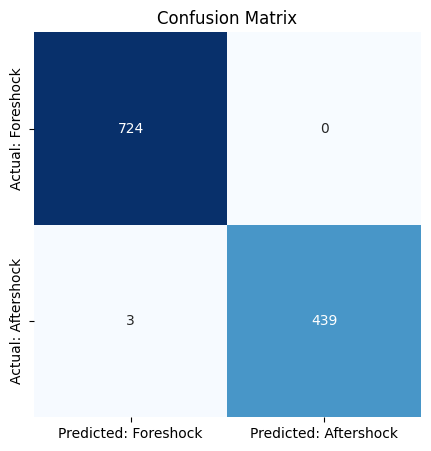

Total Accuracy: 0.9974
Total Precision: 1.0000
Total Recall: 0.9932
Total F1 Score: 0.9966
Testing Metrics for Spectrogram 64 dataset (with same amount of data for each class):


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


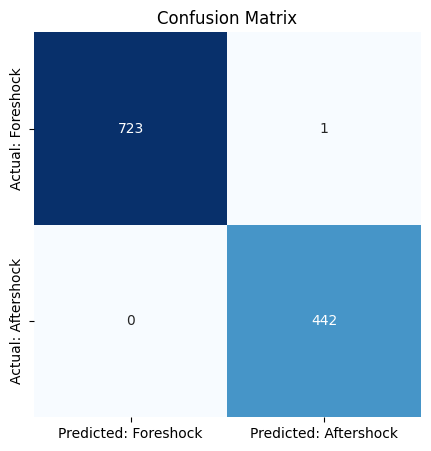

Total Accuracy: 0.9991
Total Precision: 0.9977
Total Recall: 1.0000
Total F1 Score: 0.9989


In [9]:
print("Testing Metrics for Spectrogram 64 dataset:")
compute_test_metrics(best_model_64_path, test_data_64, (33, 188))

print("Testing Metrics for Spectrogram 64 dataset (with same amount of data for each class):")
compute_test_metrics(best_model_64_path_s, test_data_64, (33, 188))

Testing Metrics for Spectrogram 32 dataset:


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


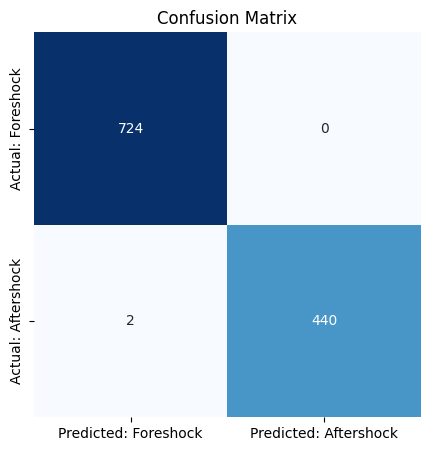

Total Accuracy: 0.9983
Total Precision: 1.0000
Total Recall: 0.9955
Total F1 Score: 0.9977
Testing Metrics for Spectrogram 32 dataset (with same amount of data for each class):


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\miche\OneDrive\Desktop\EQML Project\CNN-Explainability-on-Earthquakes\CNN_EQML\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


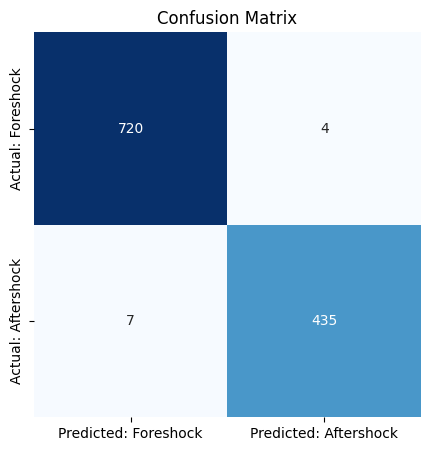

Total Accuracy: 0.9906
Total Precision: 0.9909
Total Recall: 0.9842
Total F1 Score: 0.9875


In [10]:
print("Testing Metrics for Spectrogram 32 dataset:")
compute_test_metrics(best_model_32_path, test_data_32, (17, 155))

print("Testing Metrics for Spectrogram 32 dataset (with same amount of data for each class):")
compute_test_metrics(best_model_32_path_s, test_data_32, (17, 155))